<a href="https://colab.research.google.com/github/ellenyifang2011/sea_level/blob/main/src/rnn_hyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sea Level Project**

In [18]:
import sys
import sklearn
from packaging import version

print("Welcome to the Ocean!")
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert sys.version_info >= (3, 7)

from google.colab import drive
drive.mount('/content/drive')


Welcome to the Ocean!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Get the Data

In [19]:
import os, sys
import pandas as pd

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data():
    filename="sl_raw2.csv"
    return pd.read_csv(path(filename))

_rawdata = load_data()

## Take a Quick Look at the Data Structure

In [20]:
_rawdata.info()
_rawdata.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            244 non-null    float64
 1   Sea Level Monthly Mean          244 non-null    float64
 2   Antarctic Ice Melt Rates(mass)  244 non-null    float64
 3   Greenland Ice Melt Rates(mass)  244 non-null    float64
 4   Global Temp Anomaly             244 non-null    float64
 5   El Nino                         244 non-null    float64
 6   AMOC                            196 non-null    float64
 7   CO2                             244 non-null    float64
dtypes: float64(8)
memory usage: 15.4 KB


,Date,Sea Level Monthly Mean,Antarctic Ice Melt Rates(mass),Greenland Ice Melt Rates(mass),Global Temp Anomaly,El Nino,AMOC,CO2
count,244.00000,244.000000,244.000000,244.000000,244.000000,244.000000,196.000000,244.000000
mean,2013.74500,0.083807,-1297.980615,-2934.684836,0.799959,-0.007746,16.982245,398.339303
std,6.91902,0.075083,942.498046,1818.472413,0.244191,0.827929,3.097373,16.276347
min,2002.54000,-0.166000,-2780.900000,-5608.870000,0.260000,-1.640000,8.190000,370.730000
25%,2007.68750,0.037000,-2274.782500,-4758.437500,0.620000,-0.595000,15.265000,384.387500
50%,2013.08000,0.081500,-1171.875000,-3218.780000,0.740000,-0.065000,17.070000,395.660000
75%,2020.31000,0.130000,-401.850000,-1287.797500,0.930000,0.502500,19.135000,413.667500
max,2025.37000,0.295000,82.680000,0.000000,1.480000,2.640000,24.990000,430.510000


The following cell is not shown either in the book. It creates the `images` folder (if it doesn't already exist), and it defines the `save_fig()` function which is used through this notebook to save the figures in high-res for the book.

In [21]:
#Drop the Date Column
_rawdata = _rawdata.drop('Date', axis=1)

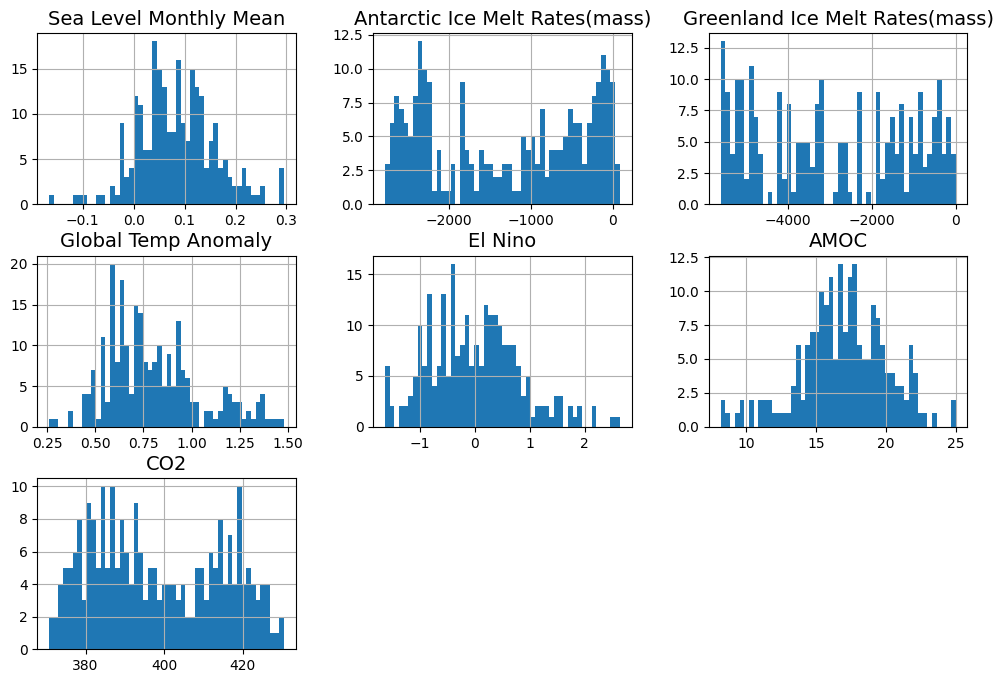

In [22]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

_rawdata.hist(bins=50, figsize=(12, 8))
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Looking for Correlations

Note: since Pandas 2.0.0, the `numeric_only` argument defaults to `False`, so we need to set it explicitly to True to avoid an error.

In [23]:
corr_matrix = _rawdata.corr(numeric_only=True)
corr_matrix["Sea Level Monthly Mean"].sort_values(ascending=False)

,Sea Level Monthly Mean
Sea Level Monthly Mean,1.000000
CO2,0.584535
Global Temp Anomaly,0.530264
El Nino,0.165736
AMOC,-0.237536
Antarctic Ice Melt Rates(mass),-0.544775
Greenland Ice Melt Rates(mass),-0.590641


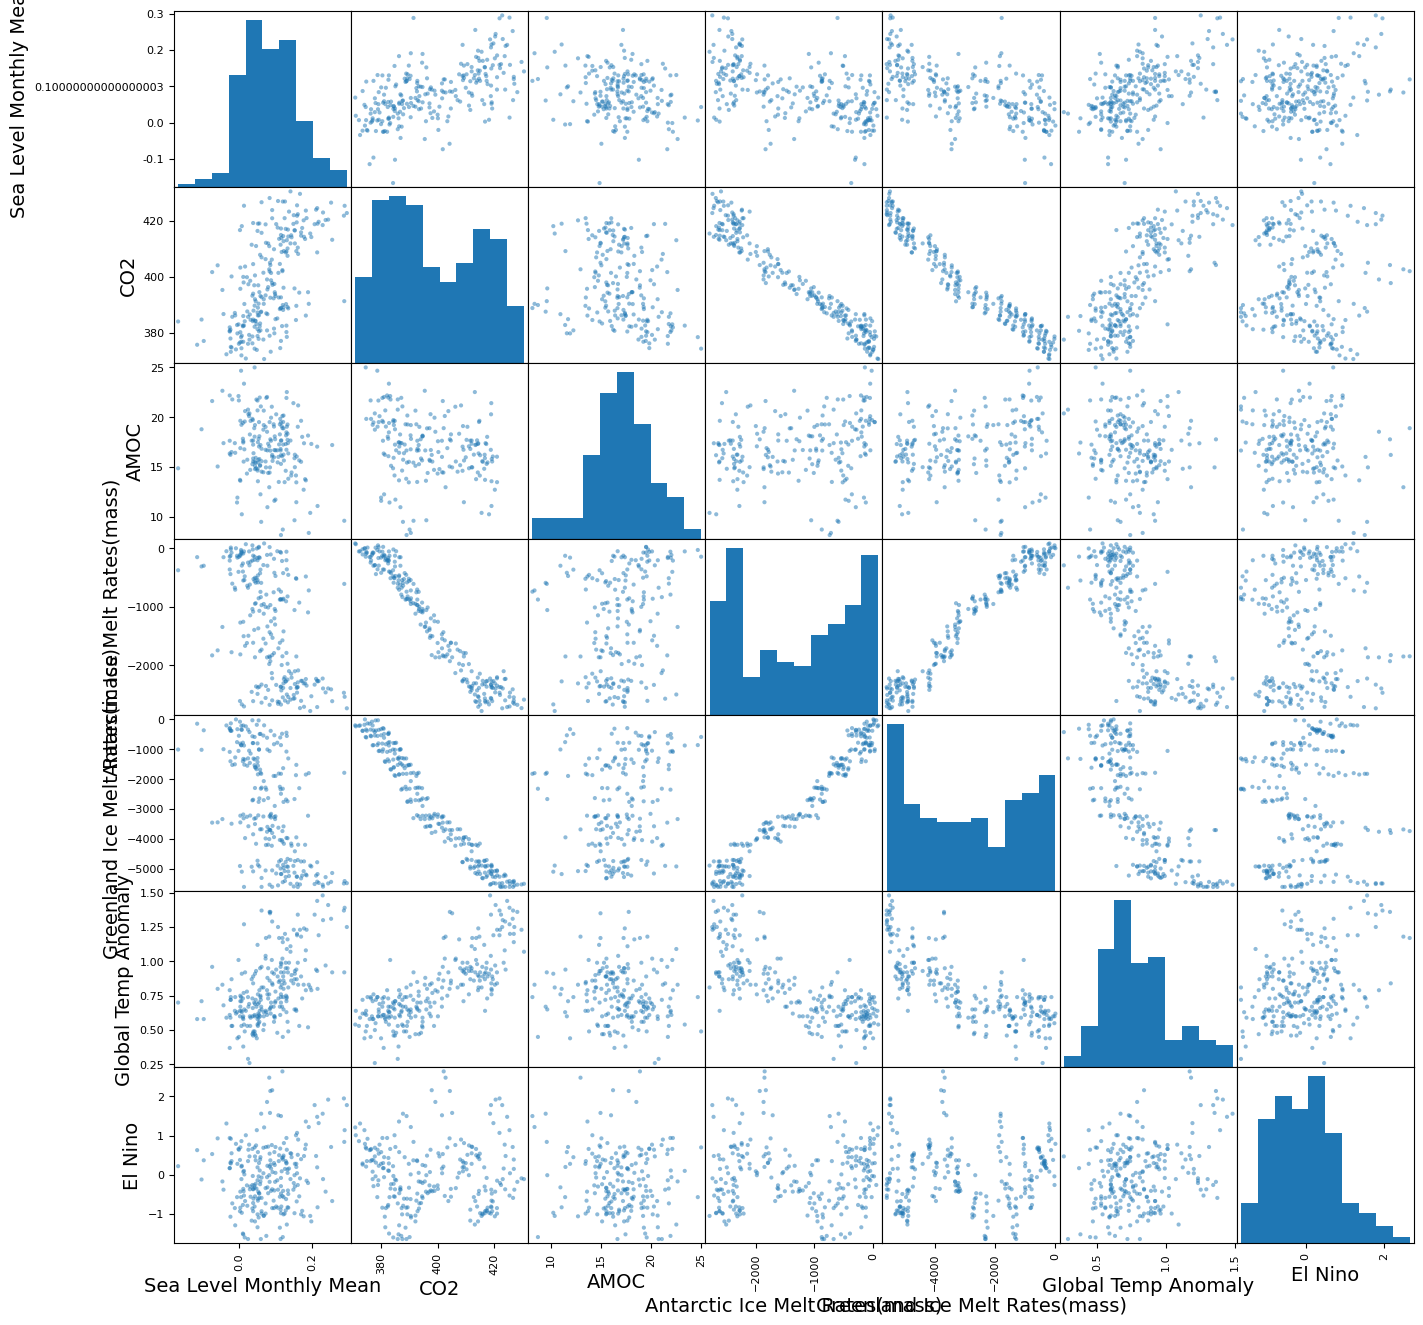

In [24]:
from pandas.plotting import scatter_matrix

attributes = ["Sea Level Monthly Mean","CO2","AMOC","Antarctic Ice Melt Rates(mass)","Greenland Ice Melt Rates(mass)","Global Temp Anomaly",	"El Nino"]
scatter_matrix(_rawdata[attributes], figsize=(16, 16))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

In [25]:
# Drop the AMOC since missing data and low correlation

_rawdata = _rawdata.drop('AMOC', axis=1)


## Create Train and Test Set

In [26]:
size_train = int(len(_rawdata) * 0.8)
size_valid = int(0.5*(len(_rawdata) - size_train))
size_test = len(_rawdata) - size_train - size_valid
print(size_train,size_valid,size_test)

mulvar_train = _rawdata.iloc[0:size_train]  * 1e3
mulvar_valid = _rawdata.iloc[size_train:size_train+size_valid] * 1e3
mulvar_test = _rawdata.iloc[size_train+size_valid:]  * 1e3

mulvar_train.info()
mulvar_valid.info()
mulvar_test.info()

195 24 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sea Level Monthly Mean          195 non-null    float64
 1   Antarctic Ice Melt Rates(mass)  195 non-null    float64
 2   Greenland Ice Melt Rates(mass)  195 non-null    float64
 3   Global Temp Anomaly             195 non-null    float64
 4   El Nino                         195 non-null    float64
 5   CO2                             195 non-null    float64
dtypes: float64(6)
memory usage: 9.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 195 to 218
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sea Level Monthly Mean          24 non-null     float64
 1   Antarctic Ice Melt Rates(mass)  24 non-null     float64
 2   Gree

In [27]:
# If needed:
# !pip -q install -U keras-tuner

import numpy as np
import tensorflow as tf
import keras_tuner as kt

def make_ds(df, seq_length, batch_size, shuffle, seed=42):
    X = df.to_numpy().astype(np.float32)
    y = df["Sea Level Monthly Mean"].to_numpy().astype(np.float32)[seq_length:]
    return tf.keras.utils.timeseries_dataset_from_array(
        X, targets=y,
        sequence_length=seq_length,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed
    )

def build_model(hp, n_features, rnn_input_len):
    rnn_type = hp.Choice("rnn_type", ["SimpleRNN", "GRU", "LSTM"])
    n_layers = hp.Int("n_layers", 1, 3)
    units = hp.Int("units", 8, 128, step=8)
    dropout = hp.Float("dropout", 0.0, 0.5, step=0.1)

    lr = hp.Choice("lr", [1e-4, 3e-4, 1e-3, 3e-3, 1e-2])
    opt_name = hp.Choice("optimizer", ["SGD", "Adam"])

    RNN = {"SimpleRNN": tf.keras.layers.SimpleRNN,
           "GRU": tf.keras.layers.GRU,
           "LSTM": tf.keras.layers.LSTM}[rnn_type]

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(rnn_input_len, n_features)))

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(RNN(units, return_sequences=return_seq, dropout=dropout))

    model.add(tf.keras.layers.Dense(1))

    if opt_name == "SGD":
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    return model

def run_tuning_for(seq_length, batch_size, max_trials=25, epochs=200):
    n_features = mulvar_train.shape[1]

    train_ds = make_ds(mulvar_train, seq_length, batch_size, shuffle=True)
    valid_ds = make_ds(mulvar_valid, seq_length, batch_size, shuffle=False)

    hypermodel = lambda hp: build_model(hp, n_features=n_features, rnn_input_len=seq_length)

    tuner = kt.BayesianOptimization(
        hypermodel=hypermodel,
        objective=kt.Objective("val_mae", direction="min"),
        max_trials=max_trials,
        directory="kt_runs",
        project_name=f"sea_level_rnn_len{seq_length}_bs{batch_size}",
        overwrite=True
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=8, min_lr=1e-6),
    ]

    tuner.search(train_ds, validation_data=valid_ds, epochs=epochs, callbacks=callbacks, verbose=0)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.get_best_models(1)[0]
    best_val_mae = tuner.get_best_trials(1)[0].metrics.get_best_value("val_mae")

    return best_val_mae, best_hp, best_model


# ---- Outer loop over seq_length / batch_size ----
candidates = [(12, 32), (12, 64), (24, 32), (24, 64), (36, 32)]
results = []

best = (np.inf, None, None, None, None)  # (mae, hp, model, seq_length, batch_size)

for seq_length, batch_size in candidates:
    mae, hp, model, sl, bs = run_tuning_for(seq_length, batch_size), None, None, None, None


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


AttributeError: 'BayesianOptimization' object has no attribute 'get_best_trials'

In [ ]:
best_val = np.inf
best_pack = None

for seq_length, batch_size in candidates:
    val_mae, best_hp, best_model = run_tuning_for(seq_length, batch_size, max_trials=25, epochs=200)
    results.append((seq_length, batch_size, val_mae, best_hp.values))
    print(f"seq={seq_length} bs={batch_size}  best_val_mae={val_mae:.6f}")

    if val_mae < best_val:
        best_val = val_mae
        best_pack = (seq_length, batch_size, best_hp, best_model)

seq_length_best, batch_size_best, hp_best, model_best = best_pack
print("\nBEST OVERALL:")
print("seq_length:", seq_length_best)
print("batch_size:", batch_size_best)
print("hp:", hp_best.values)
print("best_val_mae:", best_val)


# Select and Train a Model

## Select Simple RNN Model

In [ ]:
import tensorflow as tf
seq_length = 12
train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  # use all 5 columns as input
    targets=mulvar_train["Sea Level Monthly Mean"][seq_length:],  # forecast only the rail series
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid["Sea Level Monthly Mean"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)


In [ ]:
# extra code – defines a utility function we'll reuse several time

def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="mae", patience=50, restore_best_weights=True)
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(train_set, validation_data=valid_set, epochs=epochs,
                        callbacks=[early_stopping_cb])
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae / 1e3

Compare against the actual values:

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 6]),
    tf.keras.layers.Dense(1)
])

fit_and_evaluate(model, train_mulvar_ds, valid_mulvar_ds,
                 learning_rate=0.02, epochs=500)
#fit_and_evaluate(model, train_mulvar_ds, valid_mulvar_ds, learning_rate=0.02)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 76.8787 - mae: 77.3783 - val_loss: 147.6146 - val_mae: 148.1146
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 78.3973 - mae: 78.8973 - val_loss: 146.4767 - val_mae: 146.9767
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 73.4160 - mae: 73.9160 - val_loss: 145.0069 - val_mae: 145.5069
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 76.2789 - mae: 76.7748 - val_loss: 143.3816 - val_mae: 143.8816
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 74.1091 - mae: 74.6086 - val_loss: 141.7057 - val_mae: 142.2057
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 77.9893 - mae: 78.4879 - val_loss: 140.0309 - val_mae: 140.5309
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 70.8902 - mae: 71.3902 - val_loss: 138.3773 - val_mae: 138.8773
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 71.9755 - mae: 72.4750 - val_loss: 136.7545 - val_mae: 137.2545
Epoch 9/500
6/6 ━━━━━━━━

0.0816795654296875

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(12, return_sequences=True,input_shape=[None, 6]),
    tf.keras.layers.SimpleRNN(12, return_sequences=True),
    tf.keras.layers.Dense(1)
])

fit_and_evaluate(model, train_mulvar_ds, valid_mulvar_ds,
                 learning_rate=0.02, epochs=500)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 80.1565 - mae: 80.6548 - val_loss: 146.7227 - val_mae: 147.2227
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 79.3194 - mae: 79.8175 - val_loss: 142.2216 - val_mae: 142.7216
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 72.8002 - mae: 73.2984 - val_loss: 136.0330 - val_mae: 136.5330
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 67.5552 - mae: 68.0531 - val_loss: 128.3686 - val_mae: 128.8686
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 65.7095 - mae: 66.2094 - val_loss: 120.2098 - val_mae: 120.7098
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 58.1538 - mae: 58.6535 - val_loss: 112.1504 - val_mae: 112.6504
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 58.9828 - mae: 59.4828 - val_loss: 104.6241 - val_mae: 105.1241
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 54.4315 - mae: 54.9270 - val_loss: 98.1659 - val_mae: 98.6659
Epoch 9/500
6/6 ━━━━━━━━━━

0.08168943023681641